In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from numpy import cos
from math import log
from scipy.interpolate import interp1d
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize_scalar
from scipy.optimize import minimize
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
from scipy.optimize import fsolve
from sympy import symbols, Eq, solve

In [2]:
climate_api_data = pd.read_csv("../../data_files/data/climate_api_data_2016_2024.csv")
cases_data = pd.read_csv("../../data_files/data/sivep_notification_data/treated_malaria_notification_data/cumulative_manaus_cases_2016_2023.csv")

# Convert date columns to datetime
climate_api_data['date'] = pd.to_datetime(climate_api_data['date'])
cases_data['date'] = pd.to_datetime(cases_data['date'])

# Filter to study period
start_date = '2017-01-01'
end_date = '2023-12-31'

climate_api_data = climate_api_data[
    (climate_api_data['date'] >= start_date) & 
    (climate_api_data['date'] <= end_date)
].reset_index(drop=True)

cases_data = cases_data[
    (cases_data['date'] >= start_date) & 
    (cases_data['date'] <= end_date)
].reset_index(drop=True)

ibge_rural_pop_data_df_2016_2024 = pd.read_csv("../../data_files/data/ibge_manaus_fixed_rural_population_data_2016_2024.csv")

# Filter between dates
ibge_rural_pop_data_df_2016_2024['index'] = pd.to_datetime(ibge_rural_pop_data_df_2016_2024['index'])

# Create mask
mask = (ibge_rural_pop_data_df_2016_2024['index'] >= '2017-01-01') & (ibge_rural_pop_data_df_2016_2024['index'] <= '2023-12-31')
filtered_df = ibge_rural_pop_data_df_2016_2024[mask]
filtered_df = filtered_df.reset_index().drop(columns=['level_0'])
#filtered_df

#### Initial testing, based  on empirical parameters approximated for Amazon data

Based on /data_files/notebooks/Manaus_Population_Correction.ipynb, the approximate proportion of rural cases in the period of 2015 to 2019 was ~41.54$\%$ of the total cases. Taking this into estimation, we create an approximation of a rural cases dataframe below:

In [5]:
cases_data

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2017-01-01,2273,1963,310,2,10906,2017,1,52,1,757.666667
1,2017-01-02,2274,1962,312,4,10910,2017,1,1,2,454.800000
2,2017-01-03,2254,1951,303,5,10915,2017,1,1,3,375.666667
3,2017-01-04,2236,1936,300,1,10916,2017,1,1,4,1118.000000
4,2017-01-05,2235,1935,300,0,10916,2017,1,1,5,2235.000000
...,...,...,...,...,...,...,...,...,...,...,...
2551,2023-12-27,1110,931,179,4,47424,2023,12,52,361,222.000000
2552,2023-12-28,1102,927,175,7,47431,2023,12,52,362,137.750000
2553,2023-12-29,1098,928,170,2,47433,2023,12,52,363,366.000000
2554,2023-12-30,1088,923,165,0,47433,2023,12,52,364,1088.000000


In [6]:
rural_cases_df = cases_data.copy()
rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']] = rural_cases_df[['active_total', 'active_symptomatic', 'active_asymptomatic', 'new_cases', 'cumulative_cases', 'active_per_new_case']]*(41.54/100)
rural_cases_df

,date,active_total,active_symptomatic,active_asymptomatic,new_cases,cumulative_cases,year,month,week,day_of_year,active_per_new_case
0,2017-01-01,944.2042,815.4302,128.7740,0.8308,4530.3524,2017,1,52,1,314.734733
1,2017-01-02,944.6196,815.0148,129.6048,1.6616,4532.0140,2017,1,1,2,188.923920
2,2017-01-03,936.3116,810.4454,125.8662,2.0770,4534.0910,2017,1,1,3,156.051933
3,2017-01-04,928.8344,804.2144,124.6200,0.4154,4534.5064,2017,1,1,4,464.417200
4,2017-01-05,928.4190,803.7990,124.6200,0.0000,4534.5064,2017,1,1,5,928.419000
...,...,...,...,...,...,...,...,...,...,...,...
2551,2023-12-27,461.0940,386.7374,74.3566,1.6616,19699.9296,2023,12,52,361,92.218800
2552,2023-12-28,457.7708,385.0758,72.6950,2.9078,19702.8374,2023,12,52,362,57.221350
2553,2023-12-29,456.1092,385.4912,70.6180,0.8308,19703.6682,2023,12,52,363,152.036400
2554,2023-12-30,451.9552,383.4142,68.5410,0.0000,19703.6682,2023,12,52,364,451.955200


In [7]:
if 'active_symptomatic' in rural_cases_df.columns and 'active_asymptomatic' in rural_cases_df.columns:
    # Calculate total infectious cases
    #cases_data['total_infectious'] = cases_data['active_symptomatic'] + cases_data['active_asymptomatic']
    
    # Calculate proportion asymptomatic for model parameter
    rural_cases_df['prop_asymptomatic'] = rural_cases_df['active_asymptomatic'] / rural_cases_df['active_total']
    avg_prop_asymp = rural_cases_df['prop_asymptomatic'].mean()
    print(f"Average proportion asymptomatic: {avg_prop_asymp:.2f}")
    
    # Use total_infectious as I_H
    I_H_data = rural_cases_df['active_total'].values
    I_H0 = I_H_data[0]  # Initial infectious at start date
    
elif 'cumulative_cases' in rural_cases_df.columns:
    # If you only have cumulative cases, calculate new cases per day
    rural_cases_df['new_cases'] = rural_cases_df['cumulative_cases'].diff().fillna(0)
    I_H_data = rural_cases_df['new_cases'].values
    I_H0 = I_H_data[0]
    
else:
    # Fallback: if you only have active cases (as in this case)
    I_H_data = rural_cases_df['active_total'].values
    I_H0 = I_H_data[0]

I_H0 = round(I_H0)

print(f"Initial I_H0: {I_H0}")

Average proportion asymptomatic: 0.12
Initial I_H0: 944


In [8]:
#### Article parameters:

T_prime=25.6

# T1= 26.4 
# T2= 0.025
# omega1= 0.017
# phi1= -1.45

# R1= 250.083 
# R2= 0.565
# omega2= 0.02
# phi2=1.6

B_E=200
p_ME=0.9
p_ML=0.25
p_MP=0.75
tau_E=1
tau_P=1
c1=0.00554
c2=-0.06737
D1=36.5
b1=0.04
b2=0.09
A = 12.5
B = 15.0
C = -48.78
tau_H=10
DD=105
Tmin=14.5
gamma=1/120
R_L=32.67 #450 #968/30
N= np.round(filtered_df['daily_rural_pop'].iloc[0])  #8558
M=10000 

E_M0=5000 
#I_H0=1000

if E_M0 is None:
        E_M0 = M / 100

R_H0 = 0
I_M0 = 0

S_H0 = N - I_H0 - R_H0
S_M0 = M - E_M0 - I_M0

In [9]:
def original_model(t, z, B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
                   D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
                   N, M, use_fixed_probs=False):  

    S_H, I_H, R_H, S_M, E_M, I_M = z

    # Get the closest integer day
    day_index = int(t)
    
    T_curr = climate_api_data.loc[day_index, 'temp_med']
    R_curr = climate_api_data.loc[day_index, 'precip_med']

    # ============================================================

    # Temperature and rainfall dependent quantities

    # When use_fixed_probs=True: Apply corrections to prevent 
    # negative rates/probabilities (matches Plot_Model_Base_Functions)
    # When use_fixed_probs=True: As in the original paper (no corrections)

    def tau_L(Temp):
        """Larval development time (days)"""
        if use_fixed_probs:
            denominator = c1 * Temp + c2
            if denominator <= 0:
                return 100.0
            return 1.0 / denominator
        return 1.0 / (c1 * Temp + c2)

    def p(Temp):
        """Daily survival probability"""
        if use_fixed_probs:
            denominator = A * Temp**2 + B * Temp + C
            if denominator <= 0:
                return 0.0
            return np.exp(-1.0 / denominator)
        return np.exp(-1.0 / (A * Temp**2 + B * Temp + C))

    def p_LT(Temp):
        """Temperature-dependent larval survival"""
        return np.exp(-(c1 * Temp + c2))

    def p_LR(Rain):
        """Rainfall-dependent larval survival"""
        count_LR = (4 * p_ML / R_L**2) * Rain * (R_L - Rain)
        if use_fixed_probs:
            return np.where(count_LR <= 0, 0, count_LR)
        return count_LR

    def p_LRT(Rain, Temp):
        """Combined larval survival"""
        return p_LR(Rain) * p_LT(Temp)

    def p_ER(Rain):
        """Rainfall-dependent egg survival"""
        count_ER = (4 * p_ME / R_L**2) * Rain * (R_L - Rain)
        if use_fixed_probs:
            return np.where(count_ER <= 0, 0, count_ER)
        return count_ER

    def p_PR(Rain):
        """Rainfall-dependent pupal survival"""
        count_PR = (4 * p_MP / R_L**2) * Rain * (R_L - Rain)
        if use_fixed_probs:
            return np.where(count_PR <= 0, 0, count_PR)
        return count_PR

    def tau_M(Temp):
        """Mosquito development time (days)"""
        if use_fixed_probs:
            diff = Temp - Tmin
            if diff <= 0:
                return 1000.0
            return DD / diff
        return DD / (Temp - Tmin)

    tau_M_curr = tau_M(T_curr)

    def l_tau_M(tau_M_val, Temp, Rain):
        """Survival through development"""
        return p(Temp)**tau_M_val

    l_curr = l_tau_M(tau_M_curr, T_curr, R_curr)

    def mu(Temp):
        """Mosquito mortality rate (per day)"""
        if use_fixed_probs:
            p_val = p(Temp)
            if p_val <= 0:
                return 1.0
            return -np.log(p_val)
        return -np.log(p(Temp))

    mu_curr = mu(T_curr)

    def a(Temp, Rain):
        """Biting rate (bites per mosquito per day)"""
        a_val = (Temp - T_prime) / D1
        if use_fixed_probs:
            return np.maximum(0, a_val)
        return a_val

    a_curr = a(T_curr, R_curr)

    def b(Rain, Temp):
        """Mosquito birth rate (per day)"""
        return B_E * p_ER(Rain) * p_LRT(Rain, Temp) * p_PR(Rain) / (tau_E + tau_L(Temp) + tau_P)

    b_curr = b(R_curr, T_curr)
    
    def b3(Temp):
        """Aproximating delay behavior in ODE"""
        return 1 / tau_M(Temp)

    b3_curr = b3(T_curr)
    
    # Human equations with safeguards
    infection_rate_h = a_curr * b2 * (I_M / N) * S_H
    dShdt = -infection_rate_h
    
    dIhdt = infection_rate_h - gamma * I_H
    
    dRhdt = gamma * I_H
    
    # Mosquito equations with safeguards
    mosquito_birth = b_curr
    
    infection_rate_m = a_curr * b1 * (I_H / N) * S_M
    dSmdt = mosquito_birth - infection_rate_m - mu_curr * S_M
    
    dEmdt = infection_rate_m - (mu_curr + (b3_curr * l_curr)) * E_M
    
    dImdt = b3_curr * l_curr * E_M - mu_curr * I_M
    
    # Prevent negative derivatives from overshooting
    dShdt = max(dShdt, -S_H / 10)
    dIhdt = max(dIhdt, -I_H / 10)
    dRhdt = max(dRhdt, -R_H / 10)
    dSmdt = max(dSmdt, -S_M / 10)
    dEmdt = max(dEmdt, -E_M / 10)
    dImdt = max(dImdt, -I_M / 10)
    
    return [dShdt, dIhdt, dRhdt, dSmdt, dEmdt, dImdt]

In [10]:
initial_state = [S_H0, I_H0, R_H0, S_M0, E_M0, I_M0]

In [11]:
args = (B_E, p_ME, p_ML, p_MP, tau_E, tau_P, c1, c2,
        D1, b1, A, B, C, b2, tau_H, DD, Tmin, gamma, R_L,
        N, M, True)

t_eval = np.arange(0, 365, 0.1)  # 0.1 day steps

sol = solve_ivp(
    original_model,
    [0, 365],
    initial_state,
    args=args,
    dense_output=True,
    t_eval=t_eval,
    method="DOP853"
)

In [12]:
times = sol.t
S_H, I_H, R_H, S_M, E_M, I_M = sol.y

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


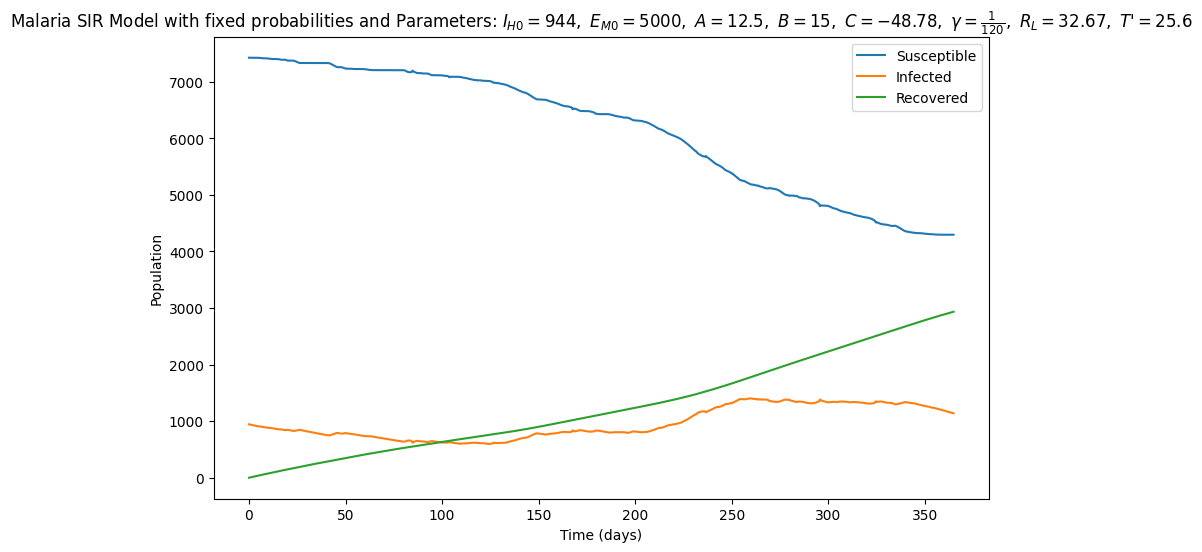

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_H, label='Susceptible')
plt.plot(times, I_H, label='Infected')
plt.plot(times, R_H, label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(
    rf"Malaria SIR Model with fixed probabilities and Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()
plt.show()

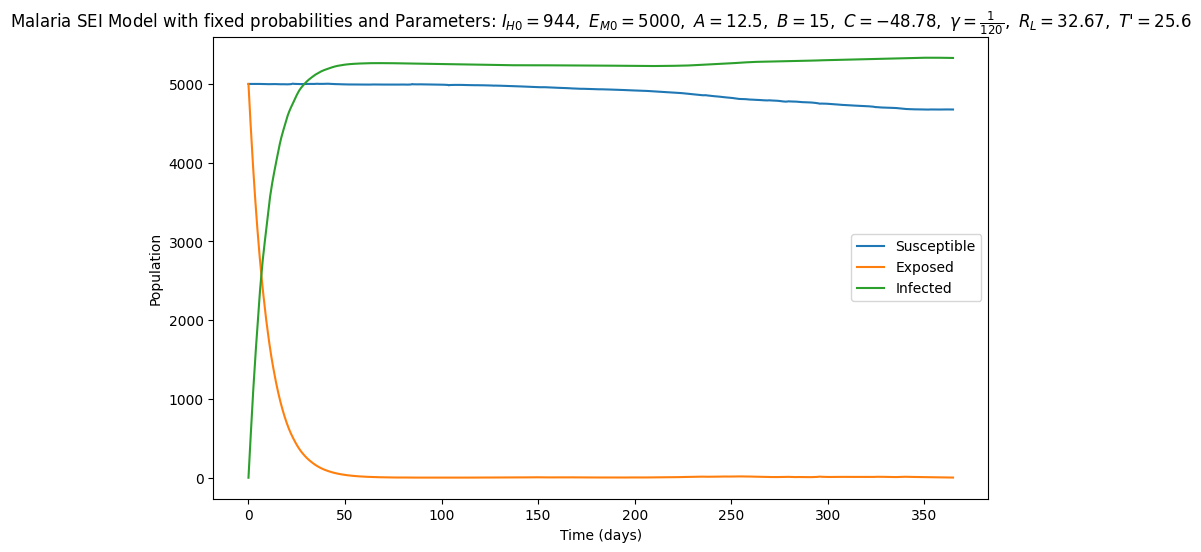

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(times, S_M, label='Susceptible')
plt.plot(times, E_M, label='Exposed')
plt.plot(times, I_M, label='Infected')

plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title(rf"Malaria SEI Model with fixed probabilities and Parameters: "
    rf"$I_{{H0}}={I_H0},\ E_{{M0}}={E_M0},\ "
    rf"A={f'{A:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"B={f'{B:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"C={f'{C:.2f}'.rstrip('0').rstrip('.')},\ "
    rf"\gamma=\frac{{1}}{{120}},\ R_L={R_L},\ "
    rf"T\text{{'}}={f'{T_prime:.2f}'.rstrip('0').rstrip('.')}$"
)

plt.legend()
plt.show()